In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Predicting Freight Cost

**Objective:** Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

* Freight is a non-trivial component of landed cost.
* Poor freight estimates distort margin and inventory planning.
* Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

In [2]:
# Establish connection to the database
conn = sqlite3.connect("C:/Users/admin/Desktop/ML Project/data/inventory.db")

In [3]:
# Query to list all tables in the database
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)

In [4]:
# Display the list of tables
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [5]:
# Loop through tables to display the first 5 rows of each
for table in tables['name']:
    print('Table name', table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
# Load the vendor_invoice table into a DataFrame
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)

In [7]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [8]:
# Calculate the correlation matrix for specific columns
vendor_df[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


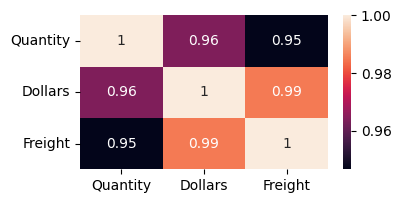

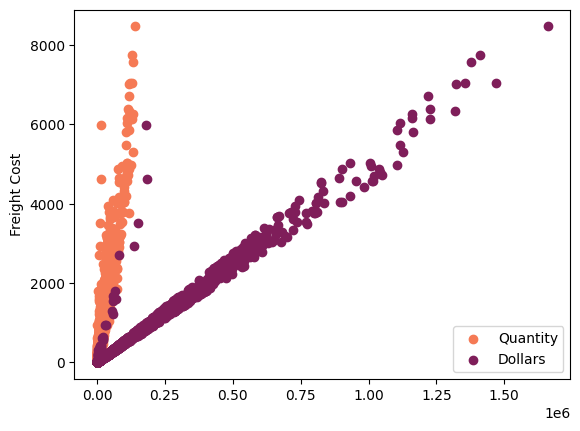

In [9]:
# Relationship between Quantity, Dollars and Freight

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot =True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'], color = '#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'], color = '#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [10]:
# Feature Engineering: Calculate freight cost per unit
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

To understand the true cost of shipping a single item, we use the following ratio:

$$\text{Freight Per Unit} = \frac{\text{Total Freight Cost}}{\text{Quantity}}$$

This is a critical metric in logistics. Generally, as quantity increases, the freight per unit decreases due to economies of scale.


In [11]:
# Display the dataframe
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [12]:
# Calculate quantiles for Quantity to identify low and high volume thresholds
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [13]:
# Display threshold values
high_quantity

np.float64(5100.5)

In [14]:
low_quantity

np.float64(83.0)

In [15]:
vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [16]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

The code uses quantiles to define "Low" and "High" volume shipments:

* **25th Percentile ($Q_1$):** Represented by `low_quantity`. This is the value below which 25% of the data points fall. In this dataset, any shipment with a quantity less than **83.0** is considered "low volume."
* **75th Percentile ($Q_3$):** Represented by `high_quantity`. This is the value below which 75% of the data points fall. Any shipment with a quantity greater than **5100.5** is considered "high volume."

The final lines use the `.loc` operator to isolate the cost efficiency of these two extreme groups:
* **Group A:** Shipments where $\text{Quantity} < Q_1$ (Smallest 25% of orders).
* **Group B:** Shipments where $\text{Quantity} > Q_3$ (Largest 25% of orders).

By comparing the `freight_per_unit` of these two groups, you can quantify exactly how much cheaper (or more expensive) it is to ship in bulk versus small batches.

In [17]:
# Feature Selection
X = vendor_df[['Dollars']]
y = vendor_df['Freight']

### Why?
- Highest correlation with target
- Simpler & stable model"


In [18]:
# Data Overview
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [19]:
# Train-Test Split
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [21]:
# Import Models and Metrics
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
# Initialize and Train Models
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [23]:
model2 = DecisionTreeRegressor(random_state = 42)
model2.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [24]:
model3 = RandomForestRegressor(random_state = 42)
model3.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [25]:
# Model Evaluation Function
import numpy

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = numpy.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

In [26]:
# Execute Evaluation
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')


Linear Regression Performance:
MAE  : 24.11
RMSE : 124.72
R²   : 96.99%

Decision Tree Regression Performance:
MAE  : 32.65
RMSE : 163.74
R²   : 94.81%

Random Forest Regression Performance:
MAE  : 28.27
RMSE : 142.21
R²   : 96.08%


# Model Performance Insights

## Linear Regression Performance
- **MAE**: 24.11  
- **RMSE**: 124.72  
- **R² Score**: 96.99%

**Insights:**
- Linear Regression achieved the **highest R² score**, indicating an excellent fit to the data.
- It also has the **lowest MAE**, which means the predicted freight values are closest to the actual values on average.
- The strong performance suggests that the relationship between **Dollars and Freight** is largely linear.
- This model provides the **best balance of accuracy and simplicity** for the current dataset.

---

## Decision Tree Regression Performance
- **MAE**: 32.65  
- **RMSE**: 163.74  
- **R² Score**: 94.81%

**Insights:**
- Decision Tree Regression showed the **lowest overall performance** among the three models.
- The comparatively higher MAE and RMSE indicate larger prediction errors.
- The model may be **slightly overfitting** to the training data, which affects its generalization on unseen data.
- Although useful for capturing non-linear patterns, it is not the best choice for this dataset.

---

## Random Forest Regression Performance
- **MAE**: 28.27  
- **RMSE**: 142.21  
- **R² Score**: 96.08%

**Insights:**
- Random Forest performed significantly better than Decision Tree Regression.
- Due to its ensemble nature, it is **more stable and less prone to overfitting**.
- It captures complex patterns effectively and gives strong predictive performance.
- However, its accuracy is still slightly lower than Linear Regression for this dataset.

---

## Final Conclusion
- **Best Model:** Linear Regression  
- **Reason:** Highest accuracy with **R² = 96.99%** and lowest prediction error values (MAE and RMSE).
- **Random Forest** serves as a strong alternative model, especially if the dataset becomes more complex in future.
- **Decision Tree Regression** is comparatively less reliable for this use case.

---

## Business Insight
- The model can accurately predict **Freight Cost based on transaction value (Dollars)**.
- This helps in:
  - **Cost optimization**
  - **Vendor performance analysis**
  - **Budget forecasting**
  - **Better supply chain decision-making**

In [27]:
X_train

,Dollars
2609,264.24
5527,342.48
5321,572.40
3805,68821.14
1215,604197.73
...,...
3772,2618.27
5191,74386.98
5226,36.96
5390,644.00


In [28]:
X_test

,Dollars
4564,352.95
1616,225706.96
4861,634.11
230,987.34
2042,31768.74
...,...
3388,242.16
1321,846.99
1322,205379.19
3618,242967.77


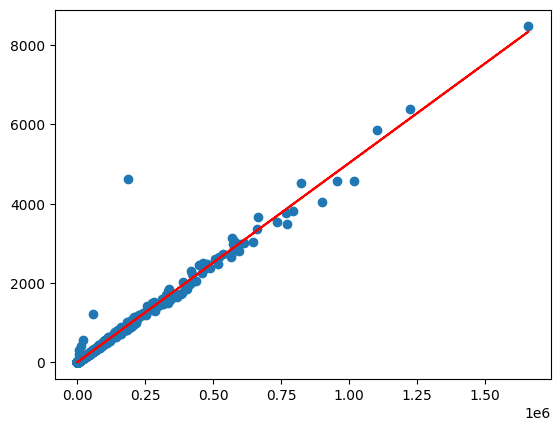

In [29]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test), color = 'red')

In [30]:
input_data = {
    "Dollars": [18500, 9000],
}

In [31]:
df = pd.DataFrame(input_data)

In [32]:
model1.predict(df)

array([97.78868161, 50.14455838])